# Viscosity Pipeline Usage Example

This notebook shows how to run the reusable viscosity pipeline on:
`results/Auto-runs/dynamic_analysis_L10000cP_siltech_A11860cP_custom_20260512_090217.csv`

Workflow covered:
1. Load dataset
2. Normalize x-axis by cell
3. Trim before-hit and after-contact zones
4. Fit Polynomial(2nd) and Hyperbola
5. Map known real viscosities (user input)
6. Extrapolate unknown viscosities
7. Plot fits and accuracy

In [4]:
import sys
from pathlib import Path

def _find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "viscometry").is_dir():
            return p
    raise RuntimeError("Could not locate repo root (expected src/viscometry)")

PROJECT_ROOT = _find_repo_root()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

AUTO_RUNS = PROJECT_ROOT / "results" / "auto_runs"
AUTO_RUNS_LEGACY = PROJECT_ROOT / "results" / "Auto-runs"
ARCHIVE = PROJECT_ROOT / "results" / "runs" / "archive"

from pathlib import Path
import sys

import pandas as pd

# Locate helper module robustly across common notebook working directories.
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / 'results' / 'Auto-runs',
    Path.cwd().parent,
]
if helper_dir is None:
from viscometry.analysis.viscosity_pipeline import run_viscosity_pipeline

In [5]:
# Dataset to analyze
#csv_path = 'full_run_260428.csv'
csv_filename = 'dynamic_analysis_L10000cP_siltech_A11860cP_custom_20260512_090217.csv'
csv_candidates = [
    Path.cwd() / csv_filename,
    helper_dir / csv_filename,
    helper_dir.parent / 'results' / 'Auto-runs' / csv_filename,
]
csv_path_obj = next((path for path in csv_candidates if path.exists()), None)
if csv_path_obj is None:
    raise FileNotFoundError(f'CSV file not found: {csv_filename}')
csv_path = str(csv_path_obj)

# USER INPUT: known calibration viscosities in cP.
# Keep only cells you trust for calibration. Unknown cells can be omitted.
real_viscosity_map = {
    1: 11860,
    2: 11860,
    3: 11860,
    4: 11860,
    5: 11860,
    6: 11860,
    7: 11860,
    8: 11860,
    9: 11860,
    10: 11860,
    11: 11860,
    12: 11860,
    13: 11860,
    14: 11860,
    15: 11860,
    16: 11860,
    17: 11860,
    18: 11860
}

# real_viscosity_map = {
#     1: 1000,
#     2: 1154,
#     3: 3347,
#     4: 6611,
#     5: 5865,
#     6: 8930,
#     7: 11860,
#     8: 14590,
#     9: 19000,
#     10: 22730,
#     11: 31870,
#     12: 40850,
#     13: 48520,
#     14: 37020,
#     15: 69080,
#     16: 70730,
#     17: 93270,
#     18: 124800,
# }

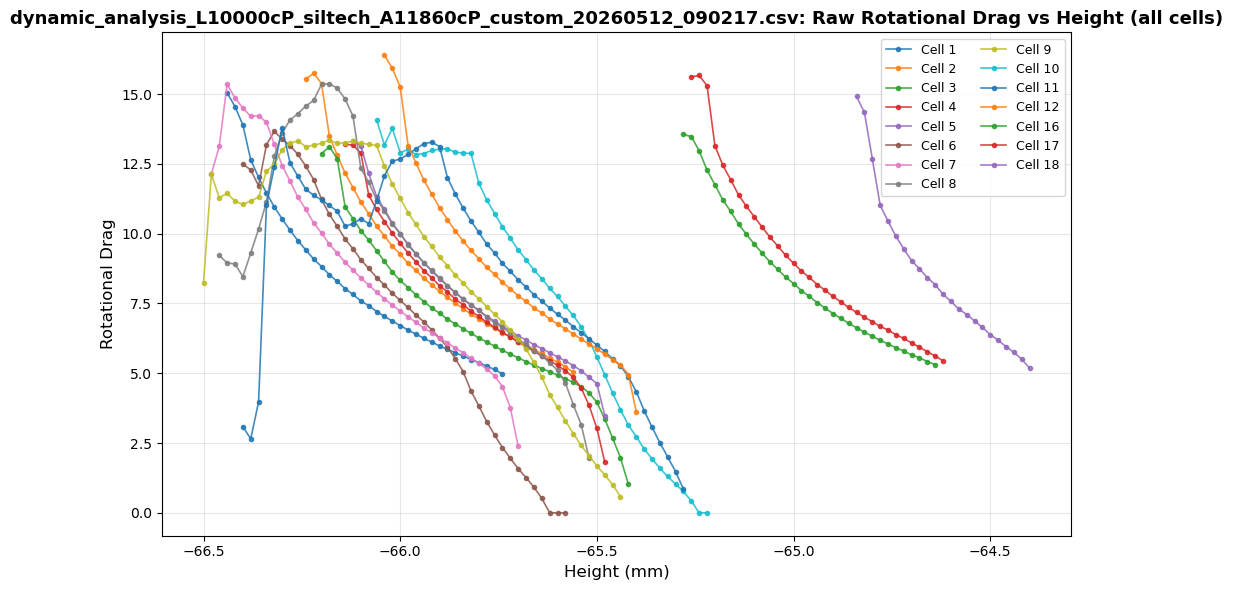

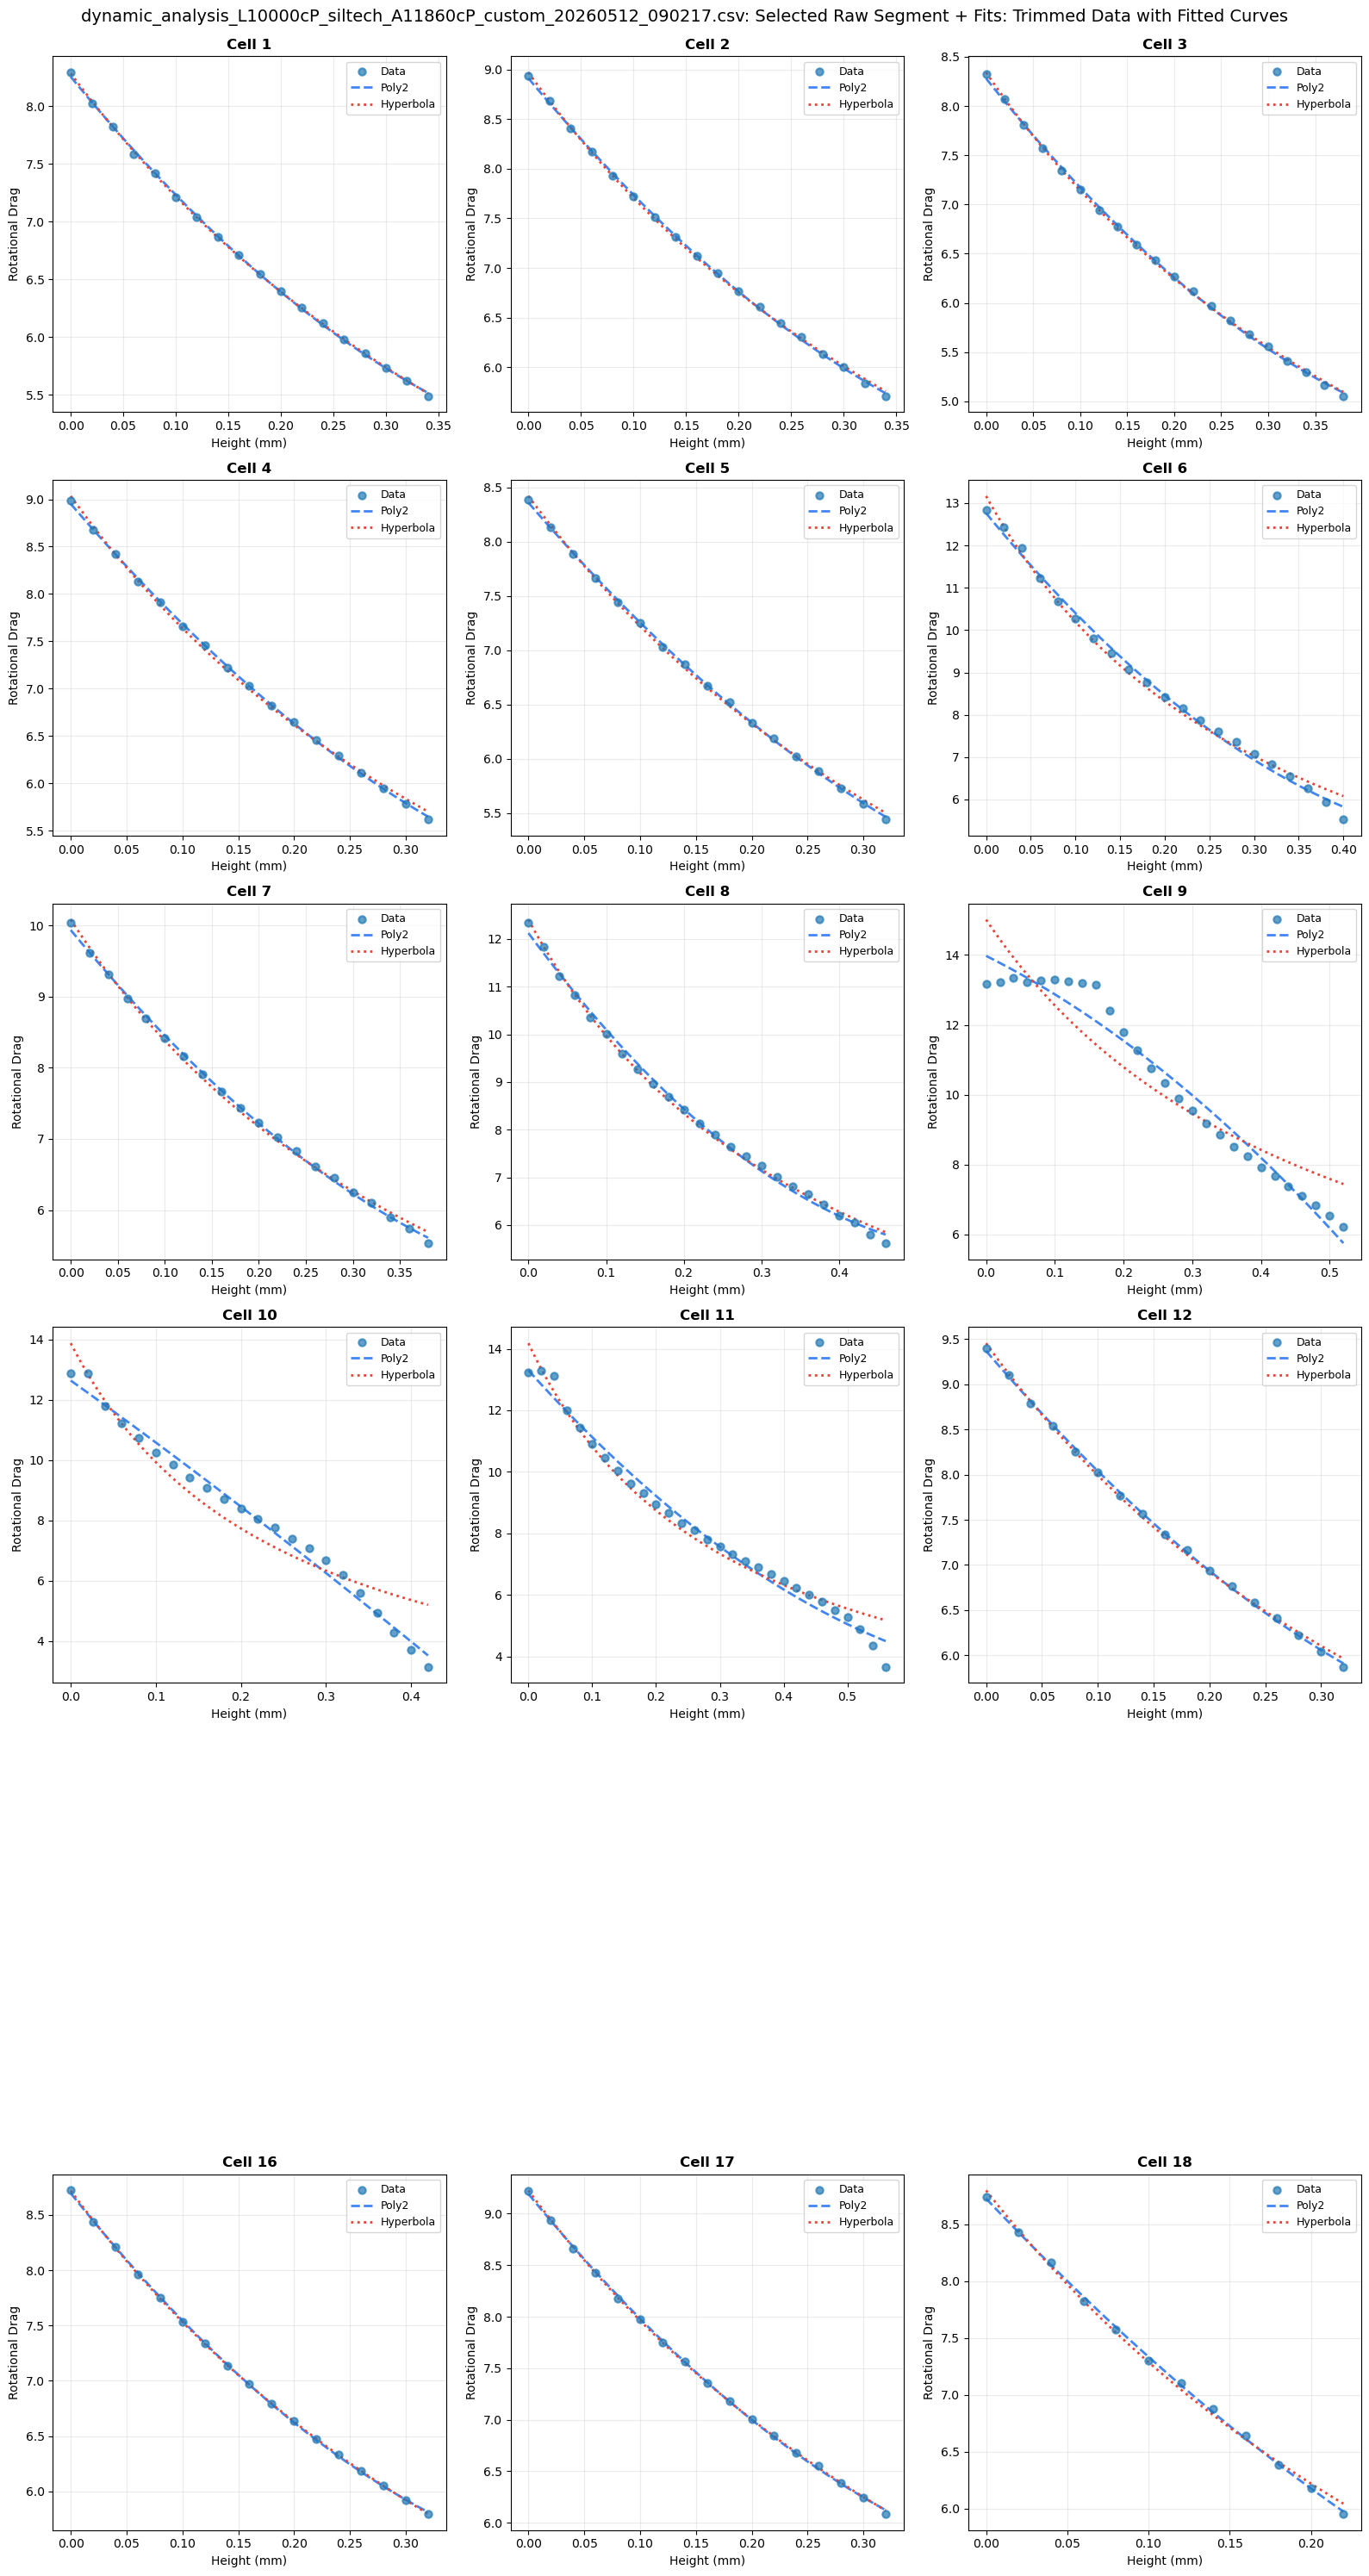

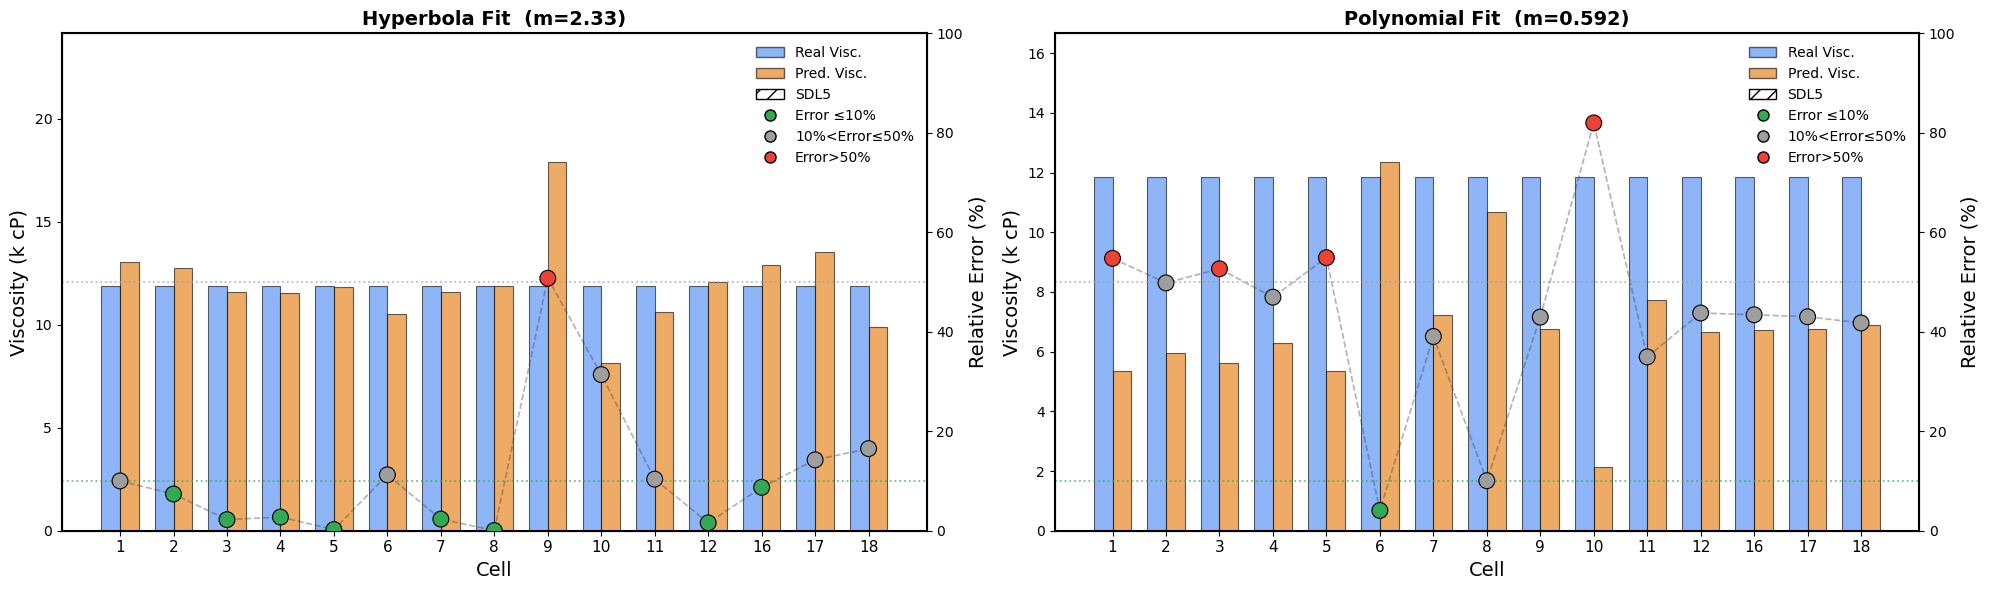

Learned scaling factors: {'poly': 0.592, 'hyperbola': 2.33}


In [6]:
pipeline_out = run_viscosity_pipeline(
    csv_path=csv_path,
    real_viscosity_map=real_viscosity_map,
    visualize=True,
)

print('Learned scaling factors:', pipeline_out['scales'])

In [7]:
pred_cols = [
    'cell',
    'a_poly2',
    'a_hyperbola',
    'real_viscosity',
    'predicted_visc_pol',
    'predicted_visc_hyp',
    'rel_error_pol',
    'rel_error_hyp',
    'is_calibration',
]

pred_df = pipeline_out['predictions'][pred_cols].sort_values('cell').reset_index(drop=True)
display(pred_df)

# Optional: save the predictions table
# pred_df.to_csv('viscosity_predictions_dynamic_analysis_L60kcP.csv', index=False)

,cell,a_poly2,a_hyperbola,real_viscosity,predicted_visc_pol,predicted_visc_hyp,rel_error_pol,rel_error_hyp,is_calibration
0,1,9.062933,5.599862,11860,5.365257,13.047679,54.761749,10.014158,True
1,2,10.052308,5.465857,11860,5.950967,12.735448,49.823216,7.381514,True
2,3,9.483943,4.976719,11860,5.614494,11.595755,52.660249,2.228035,True
3,4,10.626286,4.950536,11860,6.290762,11.534748,46.958165,2.742426,True
4,5,9.034518,5.077963,11860,5.348434,11.831653,54.903589,0.239011,True
5,6,20.848892,4.518462,11860,12.342544,10.528017,4.068667,11.230882,True
6,7,12.210919,4.971135,11860,7.228864,11.582745,39.048362,2.337735,True
7,8,18.019436,5.092247,11860,10.667506,11.864935,10.054755,0.041610,True
8,9,-11.429647,7.673847,11860,6.766351,17.880064,42.948138,50.759392,True
9,10,-3.608065,3.492427,11860,2.135974,8.137354,81.990098,31.388245,True
